In [1]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

# Deep Neural Networks 
## Session 6

## Tensor FLow
- Wines dataset
<img src='../../prasami_images/prasami_color_tutorials_small.png' width='400' alt="By Pramod Sharma : pramod.sharma@prasami.com"/>

## Import Statements

In [2]:
###-----------------
### Import libraries
###-----------------
from pathlib import Path         # Import Path for file system path operations and management
import numpy as np               # Import NumPy for numerical computations and array operations
import pandas as pd              # Import Pandas for data manipulation and analysis with DataFrames
import matplotlib.pyplot as plt  # Import Matplotlib for creating static, interactive visualizations
import seaborn as sns            # Import Seaborn for statistical data visualization built on Matplotlib

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split  # Import function to split dataset into training and testing subsets
from sklearn.metrics import (accuracy_score, 
                             classification_report, 
                             confusion_matrix, 
                             ConfusionMatrixDisplay, 
                             f1_score)                 # Import function to calculate various metric

import tensorflow as tf

2025-11-13 09:16:47.747866: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [13]:
# ###------------------
# ### Global Parameters
# ###------------------

# Directories
#inpDir = '../../input' 
inpDir = Path('..') / '..' / 'input'
# outDir = '../output'
outDir = Path('..') / 'output'


RANDOM_STATE = 42 
np.random.seed(RANDOM_STATE) # Set Random Seed for reproducible  results
tf.random.set_seed(RANDOM_STATE)

TEST_SIZE  = 0.2 # Size of test data
EPOCHS = 100
ALPHA = 0.001

# Parameters for plotting
params = {'legend.fontsize': 'medium',
          'figure.figsize': (15, 6),
          'axes.labelsize': 'large',
          'axes.titlesize':'large',
          'xtick.labelsize':'medium',
          'ytick.labelsize':'medium'
         }

CMAP = plt.cm.coolwarm

plt.rcParams.update(params)

plt.style.use('seaborn-v0_8-darkgrid') # plt.style.use('ggplot')

In [14]:
physical_devices = tf.config.list_physical_devices('GPU')

if len(physical_devices)> 0:
    tf.config.experimental.set_memory_growth(physical_devices[0], True)

In [15]:
data_df = pd.read_csv('../../input/machine_learning/wine.csv', header=None)
data_df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065,1
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050,1
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185,1
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480,1
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735,1


In [16]:
data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       178 non-null    float64
 1   1       178 non-null    float64
 2   2       178 non-null    float64
 3   3       178 non-null    float64
 4   4       178 non-null    int64  
 5   5       178 non-null    float64
 6   6       178 non-null    float64
 7   7       178 non-null    float64
 8   8       178 non-null    float64
 9   9       178 non-null    float64
 10  10      178 non-null    float64
 11  11      178 non-null    float64
 12  12      178 non-null    int64  
 13  13      178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB


In [17]:
data_df.describe().T

,count,mean,std,min,25%,50%,75%,max
0,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
1,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
2,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
3,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
4,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
5,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
6,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
7,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
8,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58
9,178.0,5.058090,2.318286,1.28,3.2200,4.690,6.2000,13.00


In [18]:
for col in data_df.columns:
    print (f'Col: {col} - {data_df[col].unique()}')

Col: 0 - [14.23 13.2  13.16 14.37 13.24 14.2  14.39 14.06 14.83 13.86 14.1  14.12
 13.75 14.75 14.38 13.63 14.3  13.83 14.19 13.64 12.93 13.71 12.85 13.5
 13.05 13.39 13.3  13.87 14.02 13.73 13.58 13.68 13.76 13.51 13.48 13.28
 13.07 14.22 13.56 13.41 13.88 14.21 13.9  13.94 13.82 13.77 13.74 13.29
 13.72 12.37 12.33 12.64 13.67 12.17 13.11 13.34 12.21 12.29 13.49 12.99
 11.96 11.66 13.03 11.84 12.7  12.   12.72 12.08 12.67 12.16 11.65 11.64
 12.69 11.62 12.47 11.81 12.6  12.34 11.82 12.51 12.42 12.25 12.22 11.61
 11.46 12.52 11.76 11.41 11.03 12.77 11.45 11.56 11.87 12.07 12.43 11.79
 12.04 12.86 12.88 12.81 12.53 12.84 13.36 13.52 13.62 12.87 13.32 13.08
 12.79 13.23 12.58 13.17 13.84 12.45 14.34 12.36 13.69 12.96 13.78 13.45
 12.82 13.4  12.2  14.16 13.27 14.13]
Col: 1 - [1.71 1.78 2.36 1.95 2.59 1.76 1.87 2.15 1.64 1.35 2.16 1.48 1.73 1.81
 1.92 1.57 1.59 3.1  1.63 3.8  1.86 1.6  2.05 1.77 1.72 1.9  1.68 1.5
 1.66 1.83 1.53 1.8  1.65 3.99 3.84 1.89 3.98 4.04 3.59 2.02 1.75 1.67
 1.

In [19]:
data_df.isna().sum()

0     0
1     0
2     0
3     0
4     0
5     0
6     0
7     0
8     0
9     0
10    0
11    0
12    0
13    0
dtype: int64

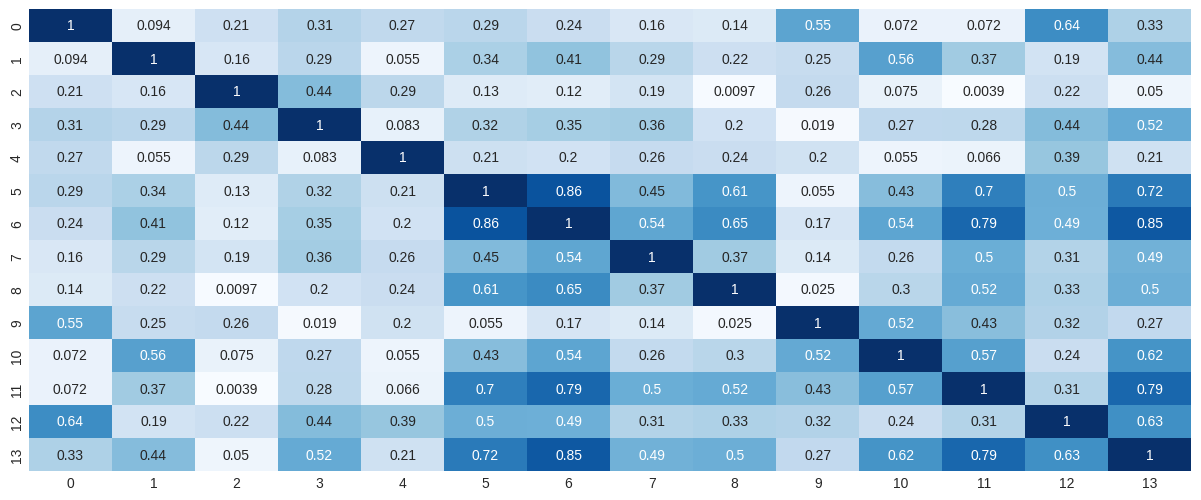

In [20]:
fig, ax = plt.subplots()
sns.heatmap(data_df.corr().abs(), 
            ax=ax, 
            cmap='Blues', 
            annot=True, 
            fmt='.2g',
            cbar=False
            );

In [21]:
labels = data_df[data_df.columns[-1]]
features_df = data_df.drop(data_df.columns[-1], axis=1)
features_df.shape, labels.shape

((178, 13), (178,))

In [23]:
X_train, X_test, y_train, y_test = train_test_split(features_df, labels, 
                                                    stratify=labels,
                                                    test_size=TEST_SIZE, 
                                                    random_state=RANDOM_STATE)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((142, 13), (36, 13), (142,), (36,))

In [24]:
sc = StandardScaler()

X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [ ]:
from sklearn.preprocessing import LabelEncoder # should be with imports

le = LabelEncoder
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

In [ ]:
def fn_softmax(z):
    exp_score = np.exp(z - np.max(z))
    return exp_score / np.sum(exp_score, axis=1, keepdims=True)

In [ ]:
sm = fn_softmax(np.asarray([[-1.0, 0, 1.0], 
                            [-10, 0, -8]]))
sm.sum(axis=1)

In [ ]:
def fn_activ(z):
    return np.tanh(z)

def fn_activ_prime(z):
    return 1.0 - np.tanh(z)**2

In [ ]:
fn_activ(np.asarray([[-1.0, 0, 1.0], [-np.inf, 0, np.inf]]))

In [ ]:
def predict(model, X_p):
    W1 = model['W1']
    W2 = model['W2']
    W3 = model['W3']
    W4 = model['W4']
    W5 = model['W5']

    b1 = model['b1']
    b2 = model['b2']
    b3 = model['b3']
    b4 = model['b4']
    b5 = model['b5']

    ## Forward Propagation
    z1 = X_p.dot(W1) + b1   # Aggregation
    a1 = fn_activ ( z1 )     # Activation

    z2 = a1.dot(W2) + b2     # Aggregation
    a2 = fn_activ ( z2 )     # Activation

    z3 = a2.dot(W3) + b3     # Aggregation
    a3 = fn_activ ( z3 )     # Activation

    z4 = a3.dot(W4) + b4     # Aggregation
    a4 = fn_activ ( z4 )     # Activation

    z5 = a4.dot(W5) + b5     # Aggregation
    a5 = fn_softmax ( z5 )   # Activation
    return a5.argmax(axis =1)
    

In [ ]:
def calculate_loss(model, X_l, y_l):
    W1 = model['W1']
    W2 = model['W2']
    W3 = model['W3']
    W4 = model['W4']
    W5 = model['W5']

    b1 = model['b1']
    b2 = model['b2']
    b3 = model['b3']
    b4 = model['b4']
    b5 = model['b5']

    m = X_l.shape[0]

    ## Forward Propagation
    z1 = X_l.dot(W1) + b1   # Aggregation
    a1 = fn_activ ( z1 )     # Activation

    z2 = a1.dot(W2) + b2     # Aggregation
    a2 = fn_activ ( z2 )     # Activation

    z3 = a2.dot(W3) + b3     # Aggregation
    a3 = fn_activ ( z3 )     # Activation

    z4 = a3.dot(W4) + b4     # Aggregation
    a4 = fn_activ ( z4 )     # Activation

    z5 = a4.dot(W5) + b5     # Aggregation
    a5 = fn_softmax ( z5 )   # Activation
    
    data_loss = -(y_l * np.log(a5) + (1-y_l)* np.log(1-a5)).sum()
    return data_loss/m

In [ ]:
def build_model(param, X_tr, y_tr, X_ts, y_ts, alpha, n_epoch):
    m = X_tr.shape[0]
    nn_output_dim = y.shape[1]
    W1 = rng.random((param['h_dim'][0], param['h_dim'][1])) / np.sqrt(param['h_dim'][0])
    W2 = rng.random((param['h_dim'][1], param['h_dim'][2])) / np.sqrt(param['h_dim'][1])
    W3 = rng.random((param['h_dim'][2], param['h_dim'][3])) / np.sqrt(param['h_dim'][2])
    W4 = rng.random((param['h_dim'][3], param['h_dim'][4])) / np.sqrt(param['h_dim'][3])
    W5 = rng.random((param['h_dim'][4], param['h_dim'][5])) / np.sqrt(param['h_dim'][4])
    
    b1 = np.zeros((1, param['h_dim'][1]))
    b2 = np.zeros((1, param['h_dim'][2]))
    b3 = np.zeros((1, param['h_dim'][3]))
    b4 = np.zeros((1, param['h_dim'][4]))
    b5 = np.zeros((1, param['h_dim'][5]))
    
    loss, tloss, epoch = [], [], []

    for i in range(n_epoch):

        ## Forward Propagation
        z1 = X_tr.dot(W1) + b1   # Aggregation
        a1 = fn_activ ( z1 )     # Activation

        z2 = a1.dot(W2) + b2     # Aggregation
        a2 = fn_activ ( z2 )     # Activation

        z3 = a2.dot(W3) + b3     # Aggregation
        a3 = fn_activ ( z3 )     # Activation

        z4 = a3.dot(W4) + b4     # Aggregation
        a4 = fn_activ ( z4 )     # Activation

        z5 = a4.dot(W5) + b5     # Aggregation
        a5 = fn_softmax ( z5 )   # Activation
        
        ## Back Propagation
        # Layer 5
        dz5 = a5 - y_tr
        assert (z5.shape == dz5.shape), f'Shape z5: {z5.shape}, {dz5.shape}'
        dW5 = (a4.T).dot(dz5)
        assert (W5.shape == dW5.shape), f'Shape W5: {W5.shape}, {dW5.shape}'
        db5 = np.sum(dz5, axis=0, keepdims=True)
        assert (b5.shape == db5.shape), f'Shape b5: {b5.shape}, {db5.shape}'
        da4 = dz5.dot(W5.T)
        assert (a4.shape == da4.shape), f'Shape a4: {a4.shape}, {da4.shape}'
        
        # Layer 4
        dz4 = da4 * fn_activ_prime(z4)
        assert (z4.shape == dz4.shape), f'Shape z4: {z4.shape}, {dz4.shape}'
        dW4 = (a3.T).dot(dz4)
        assert (W4.shape == dW4.shape), f'Shape W4 {W4.shape}, {dW4.shape}'
        db4 = np.sum(dz4, axis=0, keepdims=True)
        assert (b4.shape == db4.shape), f'Shape b4: {b4.shape}, {db4.shape}'
        da3 = dz4.dot(W4.T)
        assert (a3.shape == da3.shape), f'Shape a3: {a3.shape}, {da3.shape}'
        
        # Layer 3
        dz3 = da3 * fn_activ_prime(z3)
        assert (z3.shape == dz3.shape), f'Shape z3: {z3.shape}, {dz3.shape}'
        dW3 = (a2.T).dot(dz3)
        assert (W3.shape == dW3.shape), f'Shape W3 {W3.shape}, {dW3.shape}'
        db3 = np.sum(dz3, axis=0, keepdims=True)
        assert (b3.shape == db3.shape), f'Shape b3: {b3.shape}, {db3.shape}'
        da2 = dz3.dot(W3.T)
        assert (a2.shape == da2.shape), f'Shape a2: {a2.shape}, {da2.shape}'
        
        # Layer 2
        dz2= da2 * fn_activ_prime(z2)
        assert (z2.shape == dz2.shape), f'Shape z2: {z2.shape}, {dz2.shape}'
        dW2 = (a1.T).dot(dz2)
        assert (W2.shape == dW2.shape), f'Shape W2 {W2.shape}, {dW2.shape}'
        db2 = np.sum(dz2, axis=0, keepdims=True)
        assert (b2.shape == db2.shape), f'Shape b2: {b2.shape}, {db2.shape}'
        da1 = dz2.dot(W2.T)
        assert (a1.shape == da1.shape), f'Shape a1: {a1.shape}, {da1.shape}'

        # Layer 1:
        dz1 = da1 * fn_activ_prime(z1)
        assert (z1.shape == dz1.shape), f'Shape z1: {z1.shape}, {dz1.shape}'
        dW1 = (X_tr.T).dot(dz1)
        assert (W1.shape == dW1.shape), f'Shape W1: {W1.shape}, {dW1.shape}'
        db1 = np.sum(dz1, axis=0, keepdims=True)
        assert (b1.shape == db1.shape), f'Shape b1: {b1.shape}, {db1.shape}'
        
        W1 = W1 - alpha * dW1 / m 
        b1 = b1 - alpha * db1 / m 
        W2 = W2 - alpha * dW2 / m 
        b2 = b2 - alpha * db2 / m 
        W3 = W3 - alpha * dW3 / m 
        b3 = b3 - alpha * db3 / m 
        W4 = W4 - alpha * dW4 / m 
        b4 = b4 - alpha * db4 / m 
        W5 = W5 - alpha * dW5 / m 
        b5 = b5 - alpha * db5 / m 

        model = {'W1': W1, 'b1': b1,
                 'W2': W2, 'b2': b2,
                 'W3': W3, 'b3': b3, 
                 'W4': W4, 'b4': b4,
                 'W5': W5, 'b5': b5}

        curr_loss = calculate_loss (model, X_tr, y_tr)
        curr_ts_loss = calculate_loss (model, X_ts, y_ts)
        epoch.append(i)
        loss.append(curr_loss)
        tloss.append(curr_ts_loss)

        if i%1000 == 0:
            print (f'epoch - {i} : Loss - {curr_loss:.4f}')

    loss_hist['epoch'] = epoch
    loss_hist['loss'] = loss
    loss_hist['test_loss'] = tloss
    return model


In [ ]:
loss_hist = {}
param = {}
param['h_dim'] = [X_train.shape[1], 100, 50, 40, 30, y_train.shape[1]]
# y_train = y_train.reshape(-1,1)
y_train.shape

In [ ]:
model = build_model(param, 
                    X_train, 
                    y_train, 
                    X_test, 
                    y_test, 
                    alpha= ALPHA, 
                    n_epoch=EPOCHS)

In [ ]:
loss_df = pd.DataFrame(loss_hist)
loss_df.head()

In [ ]:
loss_df[:25000].plot(x = 'epoch', y=['loss', 'test_loss']);

In [ ]:
fn_plot_decision_boundary(X_train, y_train.argmax(axis=1), model, predict)

## Performance on training data

In [ ]:
y_pred = predict(model, X_train)
y_pred.shape, y_train.shape

In [ ]:
print (f'Accuracy: {accuracy_score(y_train.argmax(axis=1), y_pred)}')
print (classification_report(y_train.argmax(axis=1), y_pred))

In [ ]:
cm = confusion_matrix(y_train.argmax(axis=1), y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=['A', 'B'])
fig, ax = plt.subplots(figsize =(4,4))
disp.plot(ax = ax, cmap='Blues', colorbar=False)
ax.grid(False)
ax.set_title(f'F1 Score: {f1_score(y_train.argmax(axis=1), 
                                   y_pred, average='weighted'): 0.4f}');

### Performace on Test

In [ ]:
y_pred = predict(model, X_test)
y_pred.shape, y_test.shape

In [ ]:
print (f'Accuracy: {accuracy_score(y_test.argmax(axis=1), y_pred)}')
print (classification_report(y_test.argmax(axis=1), y_pred))

In [ ]:
cm = confusion_matrix(y_test.argmax(axis=1), y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=['A', 'B'])
fig, ax = plt.subplots(figsize =(4,4))
disp.plot(ax = ax, cmap='Blues', colorbar=False)
ax.grid(False)
ax.set_title(f'F1 Score: {f1_score(y_test.argmax(axis=1), 
                                   y_pred, average='weighted'): 0.4f}');